# Melanoma Classifier

In [ ]:
# Install any missing packages
#!pip install torchvision -q

import sys
print(f"Python {sys.version}")

import torch, torchvision
print(f"PyTorch {torch.__version__}")
print(f"Torchvision {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


In [ ]:
# Choose where to save outputs
import os
OUTPUT_DIR = '/AML_Project/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs will be saved to: {OUTPUT_DIR}")


## Imports

In [ ]:
import os
import time
import math
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import models, transforms
from torchvision.ops import sigmoid_focal_loss
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F

from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve, 
    precision_recall_curve
)

from IPython.display import clear_output, display


# =========================================================
# Reproducibility
# =========================================================
SEED = 42

def seed_everything(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    torch.use_deterministic_algorithms(True, warn_only=False)

    if torch.cuda.is_available():
        torch.backends.cuda.enable_flash_sdp(False)
        torch.backends.cuda.enable_mem_efficient_sdp(False)
        torch.backends.cuda.enable_math_sdp(True)

seed_everything(SEED)

def seed_worker(worker_id: int):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def make_loader_generator(seed_offset: int):
    g = torch.Generator()
    g.manual_seed(SEED + seed_offset)
    return g

print(f"Python: {os.sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"SEED: {SEED}")


## Data paths

In [ ]:
import os
import zipfile

zip_path = '/AML_Project/JPEG Melanoma 224x224.zip'
data_path = '/AML_Project/inputs/siim_isic_224'
extract_path = '/AML_Project/inputs/'

if not os.path.exists(data_path) or len(os.listdir(data_path)) == 0:
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_path)
else:
    print("Dataset already extracted. Skipping.")


Dataset already extracted. Skipping.


In [ ]:
# ── Data paths ──────────────────────
DATA_DIR  = Path("/AML_Project/inputs/siim_isic_224")   # root folder of the dataset
CSV_PATH  = DATA_DIR / "train_resized_224.csv"
IMAGE_DIR = DATA_DIR / "train"
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)

COLUMNS = ["image_name", "patient_id", "sex", "age_approx", "anatom_site_general_challenge", "diagnosis",
        "benign_malignant", "target", "resized_path"]

df = df[COLUMNS].copy()

df["image_name"] = df["image_name"].astype(str)
df["image_path"] = str(IMAGE_DIR) + "/" + df["image_name"] + ".jpg"


df["patient_id"] = df["patient_id"].astype(str)
df["target"] = df["target"].astype(int)

missing_images = (~df["image_path"].apply(lambda p: Path(p).exists())).sum()
if missing_images > 0:
    raise FileNotFoundError(
        f"{missing_images} image files were not found. Check IMAGE_DIR: {IMAGE_DIR}"
    )

if df["patient_id"].isna().sum() > 0:
    raise ValueError("Missing patient_id values found. Patient-level split would be invalid.")

print(f"Prevalence: {df['target'].mean():.5f}")


print("--- Dataset Overview ---")
print(df.head())
print(f"\nColumns: {list(df.columns)}")
print(f"Total rows: {len(df)}")
print(f"Unique groups: {df['patient_id'].nunique()}")
print(f"Positives: {int(df['target'].sum())}")
print(f"Negatives: {len(df) - int(df['target'].sum())}")
print(f"Missing patient IDs: {df['patient_id'].isna().sum()}")

Prevalence: 0.01763
--- Dataset Overview ---
     image_name  patient_id     sex  age_approx anatom_site_general_challenge  \
0  ISIC_2637011  IP_7279968    male        45.0                     head/neck   
1  ISIC_0015719  IP_3075186  female        45.0               upper extremity   
2  ISIC_0052212  IP_2842074  female        50.0               lower extremity   
3  ISIC_0068279  IP_6890425  female        45.0                     head/neck   
4  ISIC_0074268  IP_8723313  female        55.0               upper extremity   

  diagnosis benign_malignant  target  \
0   unknown           benign       0   
1   unknown           benign       0   
2     nevus           benign       0   
3   unknown           benign       0   
4   unknown           benign       0   

                                        resized_path  \
0  /kaggle/working/siim_isic_224/train/ISIC_26370...   
1  /kaggle/working/siim_isic_224/train/ISIC_00157...   
2  /kaggle/working/siim_isic_224/train/ISIC_00522...   
3  

## Sanity check — peek at one image

Sample image path: /user/HS401/ep01372/Documents/AML_Project/inputs/siim_isic_224/train/ISIC_2637011.jpg
Label (0=benign, 1=melanoma): 0
Image dimensions: (224, 224)


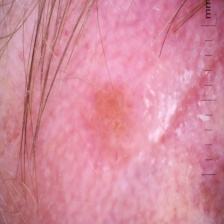

In [6]:
sample_image_path = df.loc[0, "image_path"]
sample_label = df.loc[0, "target"]

print(f"Sample image path: {sample_image_path}")
print(f"Label (0=benign, 1=melanoma): {sample_label}")

sample_image = Image.open(sample_image_path).convert("RGB")
print(f"Image dimensions: {sample_image.size}")
sample_image

## Train / Validation split (patient-level)

In [7]:
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 3
FOLDS_TO_RUN = [0, 1, 2]
RANDOM_STATE = SEED

df = df.sort_values("image_name").reset_index(drop=True)

cv_splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_splits = []
for fold, (train_idx, val_idx) in enumerate(
    cv_splitter.split(df, df["target"], groups=df["patient_id"])
):
    if fold in FOLDS_TO_RUN:
        fold_splits.append((fold, train_idx, val_idx))

print(f"Prepared folds: {FOLDS_TO_RUN}")


for fold_idx, train_idx, val_idx in fold_splits:
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    print(f"\nFold {fold_idx}")
    print(f"Train size: {len(train_df)} | positives: {int(train_df['target'].sum())} | prevalence: {train_df['target'].mean():.4f}")
    print(f"Val size:   {len(val_df)} | positives: {int(val_df['target'].sum())} | prevalence: {val_df['target'].mean():.4f}")
    print(f"Train patients: {train_df['patient_id'].nunique()}")
    print(f"Val patients:   {val_df['patient_id'].nunique()}")
    print(f"Patient overlap: {len(set(train_df['patient_id']) & set(val_df['patient_id']))}")

Prepared folds: [0, 1, 2]

Fold 0
Train size: 22080 | positives: 390 | prevalence: 0.0177
Val size:   11046 | positives: 194 | prevalence: 0.0176
Train patients: 1369
Val patients:   687
Patient overlap: 0

Fold 1
Train size: 22093 | positives: 389 | prevalence: 0.0176
Val size:   11033 | positives: 195 | prevalence: 0.0177
Train patients: 1376
Val patients:   680
Patient overlap: 0

Fold 2
Train size: 22079 | positives: 389 | prevalence: 0.0176
Val size:   11047 | positives: 195 | prevalence: 0.0177
Train patients: 1367
Val patients:   689
Patient overlap: 0


## Dataset class

In [8]:
class MelanomaDataset(Dataset):
    """Custom PyTorch Dataset for binary melanoma classification."""

    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row["target"], dtype=torch.float32)
        if self.transform is not None:
            image = self.transform(image)
        return image, label

## DataLoaders

In [9]:
TRAIN_BATCH_SIZE = 64
VAL_BATCH_SIZE   = 256
NUM_WORKERS      = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def make_train_loader(train_df, fold_idx):
    train_dataset = MelanomaDataset(train_df, transform=train_transform)
    loader_generator = make_loader_generator(1000 + fold_idx)

    if imbalance_strategy == "weighted_sampler":
        labels = train_df["target"].values.astype(int)
        class_counts = np.bincount(labels)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[labels]
        sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)

        sampler_generator = make_loader_generator(3000 + fold_idx)

        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True,
            generator=sampler_generator
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=TRAIN_BATCH_SIZE,
            sampler=sampler,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            persistent_workers=(NUM_WORKERS > 0),
            worker_init_fn=seed_worker,
            generator=loader_generator,
        )
    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=TRAIN_BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            persistent_workers=(NUM_WORKERS > 0),
            worker_init_fn=seed_worker,
            generator=loader_generator,
        )

    return train_loader

def make_val_loader(val_df, fold_idx):
    val_dataset = MelanomaDataset(val_df, transform=val_transform)
    loader_generator = make_loader_generator(2000 + fold_idx)

    val_loader = DataLoader(
        val_dataset,
        batch_size=VAL_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(NUM_WORKERS > 0),
        worker_init_fn=seed_worker,
        generator=loader_generator,
    )
    return val_loader

## Model — EfficientNet-B0

In [10]:
class MelanomaClassifier(nn.Module):
    """
    EfficientNet-B0 adapted for binary melanoma classification.
    The 1000-class head is replaced with a single linear neuron
    that outputs one logit for BCEWithLogitsLoss / Focal Loss.
    """

    def __init__(self, weights_path=None):
        super().__init__()

        if weights_path and Path(weights_path).exists():
            # --- Offline weights ---
            self.model = models.efficientnet_b0(weights=None)
            state_dict = torch.load(weights_path, map_location='cpu', weights_only=True)
            self.model.load_state_dict(state_dict)
            print(f"Loaded offline weights from {weights_path}")
        else:
            # --- Download from torchvision (requires internet) ---
            self.model = models.efficientnet_b0(weights='IMAGENET1K_V1')
            print("Downloaded ImageNet weights from torchvision")

        # Replace 1000-class head with binary head
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.model(x)

## Model custom CNN–ViT hybrid

In [11]:
class HybridTransformerEncoderLayer(nn.Module):
    """
    Transformer encoder layer with separate dropout values for:
        - attention dropout
        - feedforward / residual dropout

    Input shape:
        [batch, tokens, embed_dim]
    """


    def __init__(
        self,
        d_model,
        nhead,
        dim_feedforward,
        dropout=0.10,
        attn_dropout=0.10,
        activation="gelu",
        norm_first=True,
    ):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=attn_dropout,
            batch_first=True,
        )

        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.dropout = nn.Dropout(dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.norm_first = norm_first

        if activation == "gelu":
            self.activation = F.gelu
        elif activation == "relu":
            self.activation = F.relu
        else:
            raise ValueError(f"Unsupported activation: {activation}")

    def _self_attention_block(
        self,
        x,
        src_mask=None,
        src_key_padding_mask=None,
        is_causal=False,
    ):
        x, _ = self.self_attn(
            x,
            x,
            x,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=False,
            is_causal=is_causal,
        )
        return self.dropout1(x)

    def _feedforward_block(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return self.dropout2(x)

    def forward(
        self,
        src,
        src_mask=None,
        src_key_padding_mask=None,
        is_causal=False,
    ):
        if self.norm_first:
            src = src + self._self_attention_block(
                self.norm1(src),
                src_mask=src_mask,
                src_key_padding_mask=src_key_padding_mask,
                is_causal=is_causal,
            )
            src = src + self._feedforward_block(self.norm2(src))
        else:
            src = self.norm1(
                src + self._self_attention_block(
                    src,
                    src_mask=src_mask,
                    src_key_padding_mask=src_key_padding_mask,
                    is_causal=is_causal,
                )
            )
            src = self.norm2(src + self._feedforward_block(src))

        return src

In [12]:
class MelanomaResidualGatedHybridClassifier(nn.Module):
    """
    Residual gated EfficientNet-B0 + Transformer hybrid.

    Main path:
        cnn_logit = EfficientNet-B0 full classifier logit

    Residual path:
        CNN feature map -> 1x1 projection -> Transformer -> transformer_logit

    Final:
        final_logit = cnn_logit + sigmoid(gate_logit) * transformer_logit
    """

    def __init__(
        self,
        weights_path=None,
        transfer_model_path=None,
        embed_dim=384,
        num_heads=6,
        depth=4,
        mlp_ratio=4.0,
        dropout=0.10,
        attn_dropout=0.10,
        gate_init=-2.0,
        transformer_feature_layer_index=5,
        transformer_feature_channels=112,
        transformer_feature_grid_size=14,
        supcon_cnn_feature_dim=1280,
        supcon_fused_dim=384,
        supcon_projection_hidden_dim=384,
        supcon_projection_dim=128,
    ):

        super().__init__()

        cnn_wrapper = MelanomaClassifier(weights_path=weights_path)

        if transfer_model_path and Path(transfer_model_path).exists():
            state_dict = torch.load(
                transfer_model_path,
                map_location="cpu",
                weights_only=True
            )
            cnn_wrapper.load_state_dict(state_dict)
            print(f"Loaded baseline CNN checkpoint from {transfer_model_path}")

        self.cnn_model = cnn_wrapper.model

        self.transformer_feature_layer_index = transformer_feature_layer_index
        self.transformer_feature_channels = transformer_feature_channels
        self.transformer_feature_grid_size = transformer_feature_grid_size

        self.token_projection = nn.Conv2d(
            in_channels=self.transformer_feature_channels,
            out_channels=embed_dim,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=True,
        )

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.depth = depth
        self.mlp_ratio = mlp_ratio

    
        # EfficientNet-B0 intermediate feature map at 224x224:
        # features[0..5] produces 14x14 with 112 channels.
        self.num_tokens = self.transformer_feature_grid_size * self.transformer_feature_grid_size
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        encoder_layer = HybridTransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            attn_dropout=attn_dropout,
            activation="gelu",
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=depth,
        )


        self.transformer_norm = nn.LayerNorm(embed_dim)
        self.transformer_head = nn.Linear(embed_dim, 1)

        # SupCon fused projection path:
        # CNN pooled 1280 -> 384
        # ViT embedding 384 -> 384
        # concat 768 -> projection 128
        self.supcon_cnn_norm = nn.LayerNorm(supcon_cnn_feature_dim)
        self.supcon_cnn_projection = nn.Linear(
            supcon_cnn_feature_dim,
            supcon_fused_dim
        )

        self.supcon_vit_norm = nn.LayerNorm(embed_dim)

        self.supcon_projection_head = nn.Sequential(
            nn.LayerNorm(supcon_fused_dim + embed_dim),
            nn.Linear(supcon_fused_dim + embed_dim, supcon_projection_hidden_dim),
            nn.GELU(),
            nn.Linear(supcon_projection_hidden_dim, supcon_projection_dim),
        )



        # Scalar learnable residual gate.
        # sigmoid(-2.0) ≈ 0.119, so the model starts close to the CNN baseline.
        self.gate_logit = nn.Parameter(torch.tensor(float(gate_init)))

        self._init_new_weights()

    def _init_new_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        nn.init.kaiming_normal_(
            self.token_projection.weight,
            mode="fan_out",
            nonlinearity="relu"
        )
        if self.token_projection.bias is not None:
            nn.init.zeros_(self.token_projection.bias)

        nn.init.trunc_normal_(self.transformer_head.weight, std=0.02)
        nn.init.zeros_(self.transformer_head.bias)

        nn.init.trunc_normal_(self.supcon_cnn_projection.weight, std=0.02)
        nn.init.zeros_(self.supcon_cnn_projection.bias)

        for module in self.supcon_projection_head:
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                nn.init.zeros_(module.bias)

    def set_cnn_trainable(self, trainable):
        self.cnn_trainable = trainable

        for param in self.cnn_model.parameters():
            param.requires_grad = trainable

        if trainable:
            self.cnn_model.train()
        else:
            self.cnn_model.eval()

    def enforce_frozen_cnn_eval(self):
        if not getattr(self, "cnn_trainable", True):
            self.cnn_model.eval()

    def get_cnn_parameters(self):
        return self.cnn_model.parameters()

    def get_new_parameters(self):
        modules = [
            self.token_projection,
            self.transformer,
            self.transformer_norm,
            self.transformer_head,
            self.supcon_cnn_norm,
            self.supcon_cnn_projection,
            self.supcon_vit_norm,
            self.supcon_projection_head,
        ]

        for module in modules:
            for param in module.parameters():
                yield param

        yield self.pos_embed
        yield self.gate_logit


    def extract_features_for_cnn_and_transformer(self, x):
        """
        Extract:
            - transformer_features: intermediate 14x14 feature map
            - cnn_features: final 7x7 feature map used by EfficientNet classifier

        For torchvision EfficientNet-B0 at 224x224:
            features[5] output: [B, 112, 14, 14]
            final output:       [B, 1280, 7, 7]
        """
        transformer_features = None
        features = x

        for layer_idx, layer in enumerate(self.cnn_model.features):
            features = layer(features)

            if layer_idx == self.transformer_feature_layer_index:
                transformer_features = features

        if transformer_features is None:
            raise RuntimeError(
                f"Transformer feature layer index {self.transformer_feature_layer_index} "
                "was not reached inside cnn_model.features."
            )

        expected_channels = self.transformer_feature_channels
        expected_grid = self.transformer_feature_grid_size

        if transformer_features.shape[1] != expected_channels:
            raise RuntimeError(
                f"Unexpected transformer feature channels: "
                f"got {transformer_features.shape[1]}, expected {expected_channels}."
            )

        if transformer_features.shape[-2:] != (expected_grid, expected_grid):
            raise RuntimeError(
                f"Unexpected transformer feature spatial size: "
                f"got {tuple(transformer_features.shape[-2:])}, "
                f"expected {(expected_grid, expected_grid)}."
            )

        cnn_features = features

        return cnn_features, transformer_features


    def forward(self, x, return_features=False):
        cnn_features, transformer_features = self.extract_features_for_cnn_and_transformer(x)

        # CNN path: keep EfficientNet-B0 full classifier path.
        pooled = self.cnn_model.avgpool(cnn_features)          # [B, 1280, 1, 1]
        pooled = torch.flatten(pooled, 1)                      # [B, 1280]
        cnn_logit = self.cnn_model.classifier(pooled)          # [B, 1]

        # Transformer path: use intermediate 14x14 feature map.
        tokens = self.token_projection(transformer_features)   # [B, embed_dim, 14, 14]
        tokens = tokens.flatten(2).transpose(1, 2)             # [B, 196, embed_dim]

        tokens = tokens + self.pos_embed
        tokens = self.pos_drop(tokens)

        tokens = self.transformer(tokens)                      # [B, 196, embed_dim]
        tokens = tokens.mean(dim=1)                            # [B, embed_dim]
        transformer_embedding = self.transformer_norm(tokens)  # [B, embed_dim]

        transformer_logit = self.transformer_head(transformer_embedding)  # [B, 1]

        gate = torch.sigmoid(self.gate_logit)
        final_logit = cnn_logit + gate * transformer_logit

        if return_features:
            cnn_supcon_embedding = self.supcon_cnn_projection(
                self.supcon_cnn_norm(pooled)
            )                                                  # [B, 384]

            vit_supcon_embedding = self.supcon_vit_norm(
                transformer_embedding
            )                                                  # [B, 384]

            fused_supcon_embedding = torch.cat(
                [cnn_supcon_embedding, vit_supcon_embedding],
                dim=1
            )                                                  # [B, 768]

            supcon_projection = self.supcon_projection_head(
                fused_supcon_embedding
            )                                                  # [B, 128]

            return final_logit, transformer_embedding, supcon_projection

        return final_logit



## Model setup

In [ ]:

PRETRAINED_WEIGHTS_PATH = '/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth'

TRANSFER_MODEL_PATHS_BY_FOLD = None

FROZEN_HYBRID_PATHS_BY_FOLD = None


TRANSFER_MODEL_PATH_ALL_DEV = '/AML_Project/inputs/effb0_domainHybrid_customViT_v66_14x14_fusedSupCon_smooth_30ep_fold_0_best_model.pth'

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)



def load_full_hybrid_checkpoint(model, checkpoint_path, strict=True):
    checkpoint_path = Path(checkpoint_path)

    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Hybrid checkpoint not found: {checkpoint_path}")

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
    )

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    load_result = model.load_state_dict(state_dict, strict=strict)

    print(f"Loaded full hybrid checkpoint from: {checkpoint_path}")

    if not strict:
        print("Missing keys:", load_result.missing_keys)
        print("Unexpected keys:", load_result.unexpected_keys)

    return model



def reset_kaggle_decision_layers(model, gate_init=-3.0):
    """
    Reset Kaggle-specific decision layers after loading a domain-specific hybrid checkpoint.

    Keeps:
        - cnn_model.features
        - token_projection
        - pos_embed
        - transformer
        - transformer_norm

    Resets:
        - cnn_model.classifier[1]
        - transformer_head
        - gate_logit
    """
    if not isinstance(model.cnn_model.classifier[1], nn.Linear):
        raise TypeError("Expected model.cnn_model.classifier[1] to be nn.Linear.")

    cnn_in_features = model.cnn_model.classifier[1].in_features
    model.cnn_model.classifier[1] = nn.Linear(cnn_in_features, 1)

    nn.init.trunc_normal_(model.cnn_model.classifier[1].weight, std=0.02)
    nn.init.zeros_(model.cnn_model.classifier[1].bias)

    if not isinstance(model.transformer_head, nn.Linear):
        raise TypeError("Expected model.transformer_head to be nn.Linear.")

    transformer_in_features = model.transformer_head.in_features
    model.transformer_head = nn.Linear(transformer_in_features, 1)

    nn.init.trunc_normal_(model.transformer_head.weight, std=0.02)
    nn.init.zeros_(model.transformer_head.bias)

    with torch.no_grad():
        model.gate_logit.copy_(
            torch.tensor(float(gate_init), device=model.gate_logit.device)
        )

    return model



def build_model(
    fold_idx=None,
    use_all_dev_checkpoint=False,
    warmstart_hybrid_from_frozen=False,
):
    if warmstart_hybrid_from_frozen:
        raise ValueError(
            "Do not use warmstart_hybrid_from_frozen=True with the residual/gated hybrid. "
            "Previous hybrid checkpoints may have a different architecture."
        )

    model = MelanomaResidualGatedHybridClassifier(
        weights_path=PRETRAINED_WEIGHTS_PATH,
        transfer_model_path=None,
        embed_dim=HYBRID_EMBED_DIM,
        num_heads=HYBRID_NUM_HEADS,
        depth=HYBRID_DEPTH,
        mlp_ratio=HYBRID_MLP_RATIO,
        dropout=HYBRID_DROPOUT,
        attn_dropout=HYBRID_ATTN_DROPOUT,
        gate_init=RESIDUAL_GATE_INIT,
        transformer_feature_layer_index=HYBRID_FEATURE_LAYER_INDEX,
        transformer_feature_channels=HYBRID_FEATURE_CHANNELS,
        transformer_feature_grid_size=HYBRID_FEATURE_GRID_SIZE,
        supcon_cnn_feature_dim=SUPCON_CNN_FEATURE_DIM,
        supcon_fused_dim=SUPCON_FUSED_DIM,
        supcon_projection_hidden_dim=SUPCON_PROJECTION_HIDDEN_DIM,
        supcon_projection_dim=SUPCON_PROJECTION_DIM,
    )

    if use_all_dev_checkpoint:
        model = load_full_hybrid_checkpoint(
            model=model,
            checkpoint_path=TRANSFER_MODEL_PATH_ALL_DEV,
            strict=False,
        )

        if RESET_KAGGLE_DECISION_LAYERS:
            model = reset_kaggle_decision_layers(
                model=model,
                gate_init=KAGGLE_GATE_INIT,
            )

            print(
                f"Reset Kaggle decision layers | "
                f"gate: {get_residual_gate_value(model):.6f} | "
                f"gate_logit: {get_residual_gate_logit_value(model):.6f}"
            )




    elif TRANSFER_MODEL_PATHS_BY_FOLD is not None:
        if fold_idx is None:
            raise ValueError("fold_idx must be provided when TRANSFER_MODEL_PATHS_BY_FOLD is used.")

        model = load_full_hybrid_checkpoint(
            model=model,
            checkpoint_path=TRANSFER_MODEL_PATHS_BY_FOLD[fold_idx],
            strict=False,
        )
        if RESET_KAGGLE_DECISION_LAYERS:
            model = reset_kaggle_decision_layers(
                model=model,
                gate_init=KAGGLE_GATE_INIT,
            )

            print(
                f"Reset Kaggle decision layers | "
                f"gate: {get_residual_gate_value(model):.6f} | "
                f"gate_logit: {get_residual_gate_logit_value(model):.6f}"
            )

        

    if TRAINING_STAGE == "frozen":
        model.set_cnn_trainable(False)
    elif TRAINING_STAGE == "full_fine":
        model.set_cnn_trainable(True)
    else:
        raise ValueError(f"Invalid TRAINING_STAGE: {TRAINING_STAGE}")

    model = model.to(device)
    return model


Device: cuda:0


## Loss function & optimiser

In [14]:


class BinaryFocalLoss(nn.Module):
    def __init__(
        self,
        alpha=0.25,
        gamma=2.0,
        label_smoothing=0.0,
        reduction="mean",
    ):
        super().__init__()

        if not 0.0 <= label_smoothing < 0.5:
            raise ValueError(
                f"label_smoothing must be in [0.0, 0.5), got {label_smoothing}"
            )

        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        targets = targets.float()

        if self.label_smoothing > 0.0:
            smoothed_targets = (
                targets * (1.0 - self.label_smoothing)
                + (1.0 - targets) * self.label_smoothing
            )
        else:
            smoothed_targets = targets

        ce_loss = F.binary_cross_entropy_with_logits(
            inputs,
            smoothed_targets,
            reduction="none"
        )

        p = torch.sigmoid(inputs)
        p_t = p * smoothed_targets + (1.0 - p) * (1.0 - smoothed_targets)

        loss = ce_loss * ((1.0 - p_t) ** self.gamma)

        if self.alpha >= 0:
            alpha_t = (
                self.alpha * smoothed_targets
                + (1.0 - self.alpha) * (1.0 - smoothed_targets)
            )
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        elif self.reduction == "none":
            return loss
        else:
            raise ValueError(f"Invalid reduction: {self.reduction}")
        


def supervised_contrastive_loss(features, labels, temperature=0.07):
    """
    Supervised contrastive loss for binary or multiclass labels.

    Args:
        features: Tensor [B, D]
        labels: Tensor [B] or [B, 1]

    Returns:
        Scalar SupCon loss.
    """
    if features.ndim != 2:
        raise ValueError(f"Expected features with shape [B, D], got {features.shape}")

    labels = labels.view(-1).long()

    if features.size(0) != labels.size(0):
        raise ValueError(
            f"Batch size mismatch: features={features.size(0)}, labels={labels.size(0)}"
        )

    features = F.normalize(features, dim=1)

    batch_size = features.size(0)
    device = features.device

    similarity = torch.matmul(features, features.T) / temperature

    # Numerical stability.
    similarity = similarity - similarity.max(dim=1, keepdim=True).values.detach()

    labels_equal = labels.unsqueeze(0) == labels.unsqueeze(1)

    self_mask = torch.eye(batch_size, dtype=torch.bool, device=device)
    positive_mask = labels_equal & ~self_mask
    logits_mask = ~self_mask

    exp_logits = torch.exp(similarity) * logits_mask.float()
    log_prob = similarity - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

    positive_count = positive_mask.sum(dim=1)
    valid_anchor_mask = positive_count > 0

    if valid_anchor_mask.sum() == 0:
        return features.sum() * 0.0

    mean_log_prob_pos = (
        (positive_mask.float() * log_prob).sum(dim=1)
        / positive_count.clamp_min(1)
    )

    loss = -mean_log_prob_pos[valid_anchor_mask].mean()

    return loss


def build_training_components(model, train_df):
    criterion = BinaryFocalLoss(
        alpha=FOCAL_ALPHA,
        gamma=FOCAL_GAMMA,
        label_smoothing=LABEL_SMOOTHING,
        reduction="mean"
    ).to(device)

    if TRAINING_STAGE == "frozen":
        optimiser = optim.AdamW(
            [
                {
                    "name": "trainable",
                    "params": [p for p in model.parameters() if p.requires_grad],
                    "lr": FROZEN_LR,
                    "weight_decay": FROZEN_WEIGHT_DECAY,
                }
            ]
        )

    elif TRAINING_STAGE == "full_fine":
        optimiser = optim.AdamW(
            [
                {
                    "name": "cnn",
                    "params": [p for p in model.get_cnn_parameters() if p.requires_grad],
                    "lr": FULL_FINE_CNN_LR,
                    "weight_decay": FULL_FINE_CNN_WEIGHT_DECAY,
                },
                {
                    "name": "new",
                    "params": [p for p in model.get_new_parameters() if p.requires_grad],
                    "lr": FULL_FINE_NEW_LR,
                    "weight_decay": FULL_FINE_NEW_WEIGHT_DECAY,
                },
            ]
        )

    else:
        raise ValueError(f"Invalid TRAINING_STAGE: {TRAINING_STAGE}")

    return criterion, optimiser





In [15]:
def summarize_trainable_parameters(model):
    cnn_total = 0
    cnn_trainable = 0

    for param in model.get_cnn_parameters():
        n = param.numel()
        cnn_total += n
        if param.requires_grad:
            cnn_trainable += n

    new_total = 0
    new_trainable = 0

    for param in model.get_new_parameters():
        n = param.numel()
        new_total += n
        if param.requires_grad:
            new_trainable += n

    print(f"CNN trainable params: {cnn_trainable:,} out of {cnn_total:,}")
    print(f"New trainable params: {new_trainable:,} out of {new_total:,}")

    if TRAINING_STAGE == "frozen":
        assert cnn_trainable == 0, "CNN should be frozen, but some CNN params are trainable."
        assert new_trainable > 0, "New hybrid params should be trainable."

    elif TRAINING_STAGE == "full_fine":
        assert cnn_trainable > 0, "CNN should be trainable in full_fine stage."
        assert new_trainable > 0, "New hybrid params should be trainable."

    else:
        raise ValueError(f"Invalid TRAINING_STAGE: {TRAINING_STAGE}")

In [16]:
def get_residual_gate_value(model):
    if not hasattr(model, "gate_logit"):
        return np.nan

    with torch.no_grad():
        gate = torch.sigmoid(model.gate_logit.detach()).item()

    return float(gate)


def get_residual_gate_logit_value(model):
    if not hasattr(model, "gate_logit"):
        return np.nan

    with torch.no_grad():
        gate_logit = model.gate_logit.detach().item()

    return float(gate_logit)


def get_optimizer_lr_summary(optimiser):
    lr_summary = {}

    for idx, group in enumerate(optimiser.param_groups):
        group_name = group.get("name", f"group_{idx}")
        lr_summary[f"{group_name}_lr"] = float(group["lr"])
        lr_summary[f"{group_name}_weight_decay"] = float(group.get("weight_decay", 0.0))

    return lr_summary


def format_optimizer_lr_summary(optimiser):
    lr_summary = get_optimizer_lr_summary(optimiser)

    parts = []
    for key, value in lr_summary.items():
        if key.endswith("_lr"):
            parts.append(f"{key}: {value:.8f}")
        elif key.endswith("_weight_decay"):
            parts.append(f"{key}: {value:.6f}")

    return " | ".join(parts)



def build_per_group_cosine_scheduler(optimiser, num_epochs):
    """
    Per-param-group cosine decay.

    Desired schedule:
        cnn group: FULL_FINE_CNN_LR -> CNN_MIN_LR
        new group: FULL_FINE_NEW_LR -> NEW_MIN_LR

    This is used instead of torch.optim.lr_scheduler.CosineAnnealingLR
    because CosineAnnealingLR supports only one global eta_min.
    """
    if num_epochs <= 0:
        raise ValueError(f"num_epochs must be positive, got {num_epochs}")

    min_lrs_by_group = {
        "cnn": CNN_MIN_LR,
        "new": NEW_MIN_LR,
        "trainable": NEW_MIN_LR,
    }

    lr_lambdas = []

    for group in optimiser.param_groups:
        group_name = group.get("name", None)

        if group_name is None:
            raise ValueError(
                "Every optimizer param group must have a 'name' field "
                "to use per-group cosine scheduling."
            )

        if group_name not in min_lrs_by_group:
            raise ValueError(
                f"Unknown optimizer group name '{group_name}'. "
                f"Known groups: {list(min_lrs_by_group.keys())}"
            )

        base_lr = float(group["lr"])
        min_lr = float(min_lrs_by_group[group_name])

        if min_lr > base_lr:
            raise ValueError(
                f"min_lr must be <= base_lr for group '{group_name}'. "
                f"Got min_lr={min_lr}, base_lr={base_lr}"
            )

        min_factor = min_lr / base_lr

        def make_lambda(min_factor):
            def lr_lambda(epoch):
                epoch = min(epoch, num_epochs)
                cosine_factor = 0.5 * (1.0 + math.cos(math.pi * epoch / num_epochs))
                return min_factor + (1.0 - min_factor) * cosine_factor

            return lr_lambda
        

        def make_lambda(min_factor):
            def lr_lambda(epoch):
                if num_epochs <= 1:
                    return min_factor

                max_scheduler_epoch = num_epochs - 1
                epoch = min(epoch, max_scheduler_epoch)

                cosine_factor = 0.5 * (
                    1.0 + math.cos(math.pi * epoch / max_scheduler_epoch)
                )

                return min_factor + (1.0 - min_factor) * cosine_factor

            return lr_lambda


        lr_lambdas.append(make_lambda(min_factor))

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimiser,
        lr_lambda=lr_lambdas,
        last_epoch=-1,
    )

    return scheduler

## Experiment setup — output paths & logging

In [ ]:
imbalance_strategy = "weighted_sampler"   # "pos_weight" or "weighted_sampler"

EXPERIMENT_NAME = "effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1"

WORKING_DIR = Path(OUTPUT_DIR) / EXPERIMENT_NAME

if WORKING_DIR.exists():
    raise FileExistsError(
        f"Experiment directory already exists: {WORKING_DIR}\n"
        "Change EXPERIMENT_NAME before running to avoid overwriting previous results."
    )

WORKING_DIR.mkdir(parents=True, exist_ok=False)

print(f"Created working directory: {WORKING_DIR}")


def get_fold_paths(fold_idx):
    best_model_path      = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_best_model.pth"
    last_checkpoint_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_last_checkpoint.pth"
    log_path             = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_training_log.txt"
    return best_model_path, last_checkpoint_path, log_path

def log_message(message, log_path, printing=False):
    if printing:
        print(message)
    with open(log_path, "a") as f:
        f.write(message + "\n")



Created working directory: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1


## Training & validation functions

In [18]:
def apply_tta_transforms(images):
    """
    8x D4 TTA for NCHW tensors.

    images shape: [B, C, H, W]
    """
    return [
        images,                                      # identity
        torch.flip(images, dims=[3]),                # hflip
        torch.flip(images, dims=[2]),                # vflip
        torch.flip(images, dims=[2, 3]),             # hflip + vflip
        torch.rot90(images, k=1, dims=[2, 3]),       # rot90
        torch.flip(torch.rot90(images, k=1, dims=[2, 3]), dims=[3]),  # rot90 + hflip
        torch.rot90(images, k=2, dims=[2, 3]),       # rot180
        torch.rot90(images, k=3, dims=[2, 3]),       # rot270
    ]

In [19]:
def train_one_epoch(model, dataloader, criterion, optimiser, device, log_path=None):
    model.train()

    if hasattr(model, "enforce_frozen_cnn_eval"):
        model.enforce_frozen_cnn_eval()

    running_loss = correct = total = 0

    running_focal_loss = 0.0
    running_supcon_loss = 0.0

    running_grad_norm = 0.0
    num_grad_norm_steps = 0

    epoch_start = time.perf_counter()
    all_probs, all_labels = [], []

    for batch_idx, (images, labels) in enumerate(dataloader, start=1):
        images = images.to(device, non_blocking=True)
        labels = labels.unsqueeze(1).to(device, non_blocking=True)

        optimiser.zero_grad(set_to_none=True)


        if USE_SUPCON_LOSS:
            logits, transformer_embedding, supcon_projection = model(images, return_features=True)

            focal_loss = criterion(logits, labels)

            supcon_loss = supervised_contrastive_loss(
                features=supcon_projection,
                labels=labels.squeeze(1),
                temperature=SUPCON_TEMPERATURE,
            )

            loss = focal_loss + SUPCON_WEIGHT * supcon_loss

        else:
            logits = model(images)
            focal_loss = criterion(logits, labels)
            supcon_loss = torch.tensor(float("nan"), device=device)
            loss = focal_loss

        loss.backward()




        if USE_GRADIENT_CLIPPING:
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=GRAD_CLIP_MAX_NORM
            )
        else:
            grad_norm = torch.tensor(float("nan"), device=device)

        if USE_GRADIENT_CLIPPING:
            running_grad_norm += float(grad_norm.detach().cpu())
            num_grad_norm_steps += 1


        optimiser.step()

        probs      = torch.sigmoid(logits)
        pred       = (probs >= 0.5).float()

        bs         = images.size(0)

        running_loss += loss.item() * bs
        running_focal_loss += focal_loss.item() * bs

        if USE_SUPCON_LOSS:
            running_supcon_loss += supcon_loss.item() * bs
        else:
            running_supcon_loss += float("nan")

        correct      += (pred == labels).sum().item()
        total        += bs

        all_probs.extend(probs.squeeze(1).detach().cpu().numpy())
        all_labels.extend(labels.squeeze(1).detach().cpu().numpy())

        if (batch_idx % 10 == 0 or batch_idx == len(dataloader)) and log_path is not None: 
            elapsed = time.perf_counter() - epoch_start
            log_message(
                f"Train [{batch_idx}/{len(dataloader)}] "
                f"Loss: {running_loss/total:.4f} "
                f"Acc: {correct/total:.4f} "
                f"Elapsed: {elapsed:.1f}s",
                log_path=log_path,
                printing=False
            )

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    mean_grad_norm = (
    running_grad_norm / num_grad_norm_steps
    if num_grad_norm_steps > 0
    else float("nan")
    )

    return {
        "loss": running_loss / total,
        "focal_loss": running_focal_loss / total,
        "supcon_loss": (
            running_supcon_loss / total if USE_SUPCON_LOSS else float("nan")
        ),
        "accuracy": correct / total,
        "auroc": roc_auc_score(all_labels, all_probs),
        "auprc": average_precision_score(all_labels, all_probs),
        "grad_norm": mean_grad_norm,
    }



def validate_one_epoch(model, dataloader, criterion, device, use_tta=False, log_path=None):
    model.eval()

    running_loss = 0.0
    running_focal_loss = 0.0
    running_supcon_loss = 0.0

    correct = 0
    total = 0

    epoch_start = time.perf_counter()
    all_probs, all_labels, all_preds = [], [], []

    if use_tta and USE_SUPCON_LOSS:
        raise ValueError(
            "SupCon validation with TTA is not supported in this notebook. "
            "Use USE_TTA_EVAL=False when USE_SUPCON_LOSS=True."
        )

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader, start=1):
            images = images.to(device, non_blocking=True)
            labels = labels.unsqueeze(1).to(device, non_blocking=True)

            if use_tta:
                tta_images = apply_tta_transforms(images)

                tta_focal_losses = []
                tta_probs = []

                for aug_images in tta_images:
                    logits_aug = model(aug_images)
                    focal_loss_aug = criterion(logits_aug, labels)
                    probs_aug = torch.sigmoid(logits_aug)

                    tta_focal_losses.append(focal_loss_aug)
                    tta_probs.append(probs_aug)

                focal_loss = torch.stack(tta_focal_losses).mean()
                supcon_loss = torch.tensor(float("nan"), device=device)
                loss = focal_loss

                probs = torch.stack(tta_probs, dim=0).mean(dim=0)

            else:
                if USE_SUPCON_LOSS:
                    logits, transformer_embedding, supcon_projection = model(images, return_features=True)

                    focal_loss = criterion(logits, labels)

                    supcon_loss = supervised_contrastive_loss(
                        features=supcon_projection,
                        labels=labels.squeeze(1),
                        temperature=SUPCON_TEMPERATURE,
                    )

                    loss = focal_loss + SUPCON_WEIGHT * supcon_loss

                else:
                    logits = model(images)
                    focal_loss = criterion(logits, labels)
                    supcon_loss = torch.tensor(float("nan"), device=device)
                    loss = focal_loss

                probs = torch.sigmoid(logits)

            pred = (probs >= 0.5).float()

            bs = images.size(0)

            running_loss += loss.item() * bs
            running_focal_loss += focal_loss.item() * bs

            if USE_SUPCON_LOSS:
                running_supcon_loss += supcon_loss.item() * bs

            correct += (pred == labels).sum().item()
            total += bs

            all_probs.extend(probs.squeeze(1).cpu().numpy())
            all_labels.extend(labels.squeeze(1).cpu().numpy())
            all_preds.extend(pred.squeeze(1).cpu().numpy())

            if batch_idx % 10 == 0 or batch_idx == len(dataloader):
                elapsed = time.perf_counter() - epoch_start

                if log_path is not None:
                    log_message(
                        f"Val [{batch_idx}/{len(dataloader)}] "
                        f"Loss: {running_loss / total:.4f} "
                        f"FocalLoss: {running_focal_loss / total:.4f} "
                        f"SupConLoss: "
                        f"{(running_supcon_loss / total if USE_SUPCON_LOSS else float('nan')):.4f} "
                        f"Acc: {correct / total:.4f} "
                        f"Elapsed: {elapsed:.1f}s",
                        log_path=log_path,
                        printing=False
                    )

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "loss": running_loss / total,
        "focal_loss": running_focal_loss / total,
        "supcon_loss": (
            running_supcon_loss / total
            if USE_SUPCON_LOSS
            else float("nan")
        ),
        "accuracy": correct / total,
        "auroc": roc_auc_score(all_labels, all_probs),
        "auprc": average_precision_score(all_labels, all_probs),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "specificity": specificity,
        "confusion_matrix": cm,
        "all_probs": all_probs,
        "all_labels": all_labels,
        "all_preds": all_preds,
    }

In [20]:
def threshold_sweep(y_true, y_prob, thresholds=np.arange(0.05, 0.96, 0.05)):
    results = []

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        results.append({
            "threshold": float(thr),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "specificity": specificity,
        })

    return pd.DataFrame(results)

## Training loop

In [21]:
TRAINING_STAGE = "full_fine"   # "frozen" or "full_fine"

FOCAL_ALPHA = 0.80     
FOCAL_GAMMA = 2.0     
LABEL_SMOOTHING = 0.05   
 
HYBRID_EMBED_DIM = 384
HYBRID_NUM_HEADS = 6
HYBRID_DEPTH = 4
HYBRID_MLP_RATIO = 4.0
HYBRID_DROPOUT = 0.20
HYBRID_ATTN_DROPOUT = 0.15    

HYBRID_FEATURE_LAYER_INDEX = 5
HYBRID_FEATURE_GRID_SIZE = 14
HYBRID_FEATURE_CHANNELS = 112

USE_SUPCON_LOSS = True
SUPCON_WEIGHT = 0.01          
SUPCON_TEMPERATURE = 0.12     

SUPCON_CNN_FEATURE_DIM = 1280
SUPCON_FUSED_DIM = 384
SUPCON_PROJECTION_HIDDEN_DIM = 384
SUPCON_PROJECTION_DIM = 128

RESIDUAL_GATE_INIT = -1.5 

RESET_KAGGLE_DECISION_LAYERS = True
KAGGLE_GATE_INIT = -3.0

FROZEN_LR = 3e-4
FROZEN_WEIGHT_DECAY = 0.05


FULL_FINE_CNN_LR = 1e-5
FULL_FINE_NEW_LR = 1e-4

FULL_FINE_CNN_WEIGHT_DECAY = 0.05
FULL_FINE_NEW_WEIGHT_DECAY = 0.15

USE_COSINE_LR = True

CNN_MIN_LR = 1e-6   #v6.1 CNN_MIN_LR = 1e-6
NEW_MIN_LR = 1e-5   #v6.3 NEW_MIN_LR = 1e-4

USE_GRADIENT_CLIPPING = True
GRAD_CLIP_MAX_NORM = 1.0




In [22]:
num_epochs = 30
USE_TTA = False
checkpoint_metric = "auprc"   # "auroc" or "auprc"
WARMSTART_HYBRID = False
USE_ALL_DEV_CHECKPOINT = True

USE_EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 6
EARLY_STOPPING_MIN_DELTA = 1e-4

all_fold_results = []

full_training_start = time.perf_counter()

for fold_idx, train_idx, val_idx in fold_splits:
    print(f"\n===== Fold {fold_idx} =====")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    print(f"Train size: {len(train_df)} | positives: {int(train_df['target'].sum())}")
    print(f"Val size:   {len(val_df)} | positives: {int(val_df['target'].sum())}")

    train_loader = make_train_loader(train_df, fold_idx=fold_idx)
    val_loader = make_val_loader(val_df, fold_idx=fold_idx)

    model = build_model(
        fold_idx=fold_idx,
        use_all_dev_checkpoint=USE_ALL_DEV_CHECKPOINT,
        warmstart_hybrid_from_frozen=WARMSTART_HYBRID,
    )

    summarize_trainable_parameters(model)


    criterion, optimiser = build_training_components(model, train_df)

    scheduler = None
    if USE_COSINE_LR:
        scheduler = build_per_group_cosine_scheduler(
            optimiser=optimiser,
            num_epochs=num_epochs,
        )


    initial_gate = get_residual_gate_value(model)
    initial_gate_logit = get_residual_gate_logit_value(model)
    optimizer_summary = format_optimizer_lr_summary(optimiser)
    scheduler_name = "per_group_cosine" if scheduler is not None else "none"

    print(f"Initial residual gate: {initial_gate:.6f} | gate_logit: {initial_gate_logit:.6f}")
    print(f"Optimizer groups: {optimizer_summary}")
    print(f"Scheduler: {scheduler_name}")

    BEST_MODEL_PATH, LAST_CHECKPOINT_PATH, LOG_PATH = get_fold_paths(fold_idx)

    with open(LOG_PATH, "w") as f:
        f.write(f"Training log started at {datetime.now()}\n")
        f.write(f"TRAINING_STAGE: {TRAINING_STAGE}\n")
        f.write(f"KAGGLE_GATE_INIT: {KAGGLE_GATE_INIT}\n")
        f.write(f"HYBRID_DROPOUT: {HYBRID_DROPOUT}\n")
        f.write(f"HYBRID_ATTN_DROPOUT: {HYBRID_ATTN_DROPOUT}\n")
        f.write(f"HYBRID_FEATURE_LAYER_INDEX: {HYBRID_FEATURE_LAYER_INDEX}\n")
        f.write(f"HYBRID_FEATURE_CHANNELS: {HYBRID_FEATURE_CHANNELS}\n")
        f.write(f"HYBRID_FEATURE_GRID_SIZE: {HYBRID_FEATURE_GRID_SIZE}\n")
        f.write(f"HYBRID_NUM_TOKENS: {HYBRID_FEATURE_GRID_SIZE * HYBRID_FEATURE_GRID_SIZE}\n")
        f.write(f"Initial residual gate: {initial_gate:.6f}\n")
        f.write(f"Initial residual gate_logit: {initial_gate_logit:.6f}\n")
        f.write(f"Optimizer groups: {optimizer_summary}\n")
        f.write(f"FULL_FINE_CNN_WEIGHT_DECAY: {FULL_FINE_CNN_WEIGHT_DECAY}\n")
        f.write(f"FULL_FINE_NEW_WEIGHT_DECAY: {FULL_FINE_NEW_WEIGHT_DECAY}\n")
        f.write(f"Scheduler: {scheduler_name}\n")
        f.write(f"CNN_MIN_LR: {CNN_MIN_LR}\n")
        f.write(f"NEW_MIN_LR: {NEW_MIN_LR}\n")
        f.write(f"USE_GRADIENT_CLIPPING: {USE_GRADIENT_CLIPPING}\n")
        f.write(f"GRAD_CLIP_MAX_NORM: {GRAD_CLIP_MAX_NORM}\n")
        f.write(f"FOCAL_ALPHA: {FOCAL_ALPHA}\n")
        f.write(f"FOCAL_GAMMA: {FOCAL_GAMMA}\n")
        f.write(f"LABEL_SMOOTHING: {LABEL_SMOOTHING}\n")
        f.write(f"USE_SUPCON_LOSS: {USE_SUPCON_LOSS}\n")
        if USE_SUPCON_LOSS:
            f.write(f"SUPCON_WEIGHT: {SUPCON_WEIGHT}\n")
            f.write(f"SUPCON_TEMPERATURE: {SUPCON_TEMPERATURE}\n")
            f.write(f"SUPCON_CNN_FEATURE_DIM: {SUPCON_CNN_FEATURE_DIM}\n")
            f.write(f"SUPCON_FUSED_DIM: {SUPCON_FUSED_DIM}\n")
            f.write(f"SUPCON_PROJECTION_HIDDEN_DIM: {SUPCON_PROJECTION_HIDDEN_DIM}\n")
            f.write(f"SUPCON_PROJECTION_DIM: {SUPCON_PROJECTION_DIM}\n\n")
        f.write(f"USE_EARLY_STOPPING: {USE_EARLY_STOPPING}\n")
        f.write(f"EARLY_STOPPING_PATIENCE: {EARLY_STOPPING_PATIENCE}\n")
        f.write(f"EARLY_STOPPING_MIN_DELTA: {EARLY_STOPPING_MIN_DELTA}\n\n")

        
    best_val_metric = -1.0
    best_epoch = -1
    best_gate = np.nan
    best_gate_logit = np.nan

    epochs_without_improvement = 0
    early_stopped = False
    early_stop_epoch = None

    fold_history = {
        "epoch": [],
        "train_loss": [],
        "train_focal_loss": [],
        "train_supcon_loss": [],
        "val_loss": [],
        "val_focal_loss": [],
        "val_supcon_loss": [],
        "train_auroc": [],
        "val_auroc": [],
        "train_auprc": [],
        "val_auprc": [],
        "val_f1": [],
        "gate": [],
        "gate_logit": [],
        "cnn_lr": [],
        "new_lr": [],
        "cnn_weight_decay": [],
        "new_weight_decay": [],
        "train_grad_norm": [],
    }

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.perf_counter()

        lr_summary_text = format_optimizer_lr_summary(optimiser)

        current_gate = get_residual_gate_value(model)
        current_gate_logit = get_residual_gate_logit_value(model)

        log_message(
            f"Starting epoch {epoch}/{num_epochs}... | "
            f"{lr_summary_text} | "
            f"gate: {current_gate:.6f} | gate_logit: {current_gate_logit:.6f}",
            log_path=LOG_PATH,
            printing=True
        )

        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimiser,
            device,
            log_path=LOG_PATH
        )

        val_metrics = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device,
            use_tta=USE_TTA,
            log_path=LOG_PATH
        )

        epoch_duration = time.perf_counter() - epoch_start

        epoch_gate = get_residual_gate_value(model)
        epoch_gate_logit = get_residual_gate_logit_value(model)
        epoch_lr_summary = get_optimizer_lr_summary(optimiser)

        fold_history["epoch"].append(epoch)

        fold_history["train_loss"].append(train_metrics["loss"])
        fold_history["train_focal_loss"].append(train_metrics.get("focal_loss", np.nan))
        fold_history["train_supcon_loss"].append(train_metrics.get("supcon_loss", np.nan))

        fold_history["val_loss"].append(val_metrics["loss"])
        fold_history["val_focal_loss"].append(val_metrics.get("focal_loss", np.nan))
        fold_history["val_supcon_loss"].append(val_metrics.get("supcon_loss", np.nan))

        fold_history["train_auroc"].append(train_metrics["auroc"])
        fold_history["val_auroc"].append(val_metrics["auroc"])

        fold_history["train_auprc"].append(train_metrics["auprc"])
        fold_history["val_auprc"].append(val_metrics["auprc"])

        fold_history["val_f1"].append(val_metrics["f1"])

        fold_history["train_grad_norm"].append(train_metrics.get("grad_norm", np.nan))

        fold_history["gate"].append(epoch_gate)
        fold_history["gate_logit"].append(epoch_gate_logit)

        fold_history["cnn_lr"].append(epoch_lr_summary.get("cnn_lr", np.nan))
        fold_history["new_lr"].append(epoch_lr_summary.get("new_lr", np.nan))

        fold_history["cnn_weight_decay"].append(epoch_lr_summary.get("cnn_weight_decay", np.nan))
        fold_history["new_weight_decay"].append(epoch_lr_summary.get("new_weight_decay", np.nan))
        


        log_message(
            f"Training | "
            f"Loss: {train_metrics['loss']:.4f} | "
            f"FocalLoss: {train_metrics.get('focal_loss', np.nan):.4f} | "
            f"SupConLoss: {train_metrics.get('supcon_loss', np.nan):.4f} | "
            f"Acc: {train_metrics['accuracy']:.4f} |"
            f"AUROC: {train_metrics['auroc']:.4f} | "
            f"AUPRC: {train_metrics['auprc']:.4f} | "
            f"GradNorm: {train_metrics.get('grad_norm', np.nan):.4f}",
            log_path=LOG_PATH,
            printing=True
        )


        log_message(
            f"Validation | Loss: {val_metrics['loss']:.4f} | "
            f"FocalLoss: {val_metrics.get('focal_loss', np.nan):.4f} | "
            f"SupConLoss: {val_metrics.get('supcon_loss', np.nan):.4f} | "
            f"Acc: {val_metrics['accuracy']:.4f} | AUROC: {val_metrics['auroc']:.4f} | AUPRC: {val_metrics['auprc']:.4f} | "
            f"Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f} | "
            f"Specificity: {val_metrics['specificity']:.4f} | F1: {val_metrics['f1']:.4f} | "
            f"GradNorm: {train_metrics.get('grad_norm', np.nan):.4f}",
            log_path=LOG_PATH,
            printing=True
        )

        cm = val_metrics["confusion_matrix"]
        tn, fp, fn, tp = cm.ravel()
        log_message(
            f"Confusion Matrix: TN={tn}  FP={fp}  FN={fn}  TP={tp}",
            log_path=LOG_PATH,
            printing=True
        )

        log_message(
            f"Epoch duration: {epoch_duration:.1f}s ({epoch_duration / 60:.2f} min)",
            log_path=LOG_PATH,
            printing=True
        )


        current_metric = val_metrics[checkpoint_metric]

        is_valid_metric = not math.isnan(current_metric)
        is_improvement = (
            is_valid_metric
            and current_metric > best_val_metric + EARLY_STOPPING_MIN_DELTA
        )

        if is_improvement:
            best_val_metric = current_metric
            best_epoch = epoch
            best_gate = epoch_gate
            best_gate_logit = epoch_gate_logit
            epochs_without_improvement = 0

            torch.save(model.state_dict(), BEST_MODEL_PATH)

            log_message("-" * 80, log_path=LOG_PATH, printing=True)

            log_message(
                f"Best model saved ({checkpoint_metric.upper()} {best_val_metric:.4f}) | "
                f"best_gate: {best_gate:.6f} | best_gate_logit: {best_gate_logit:.6f}",
                log_path=LOG_PATH,
                printing=True
            )

        else:
            if is_valid_metric:
                epochs_without_improvement += 1

            log_message(
                f"No improvement for {epochs_without_improvement}/"
                f"{EARLY_STOPPING_PATIENCE} epochs | "
                f"current_{checkpoint_metric}: {current_metric:.6f} | "
                f"best_{checkpoint_metric}: {best_val_metric:.6f}",
                log_path=LOG_PATH,
                printing=True
            )


        
        log_message("=" * 160, log_path=LOG_PATH, printing=True)

            
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimiser_state_dict": optimiser.state_dict(),
                "best_val_metric": best_val_metric,
                "best_epoch": best_epoch,
                "best_gate": best_gate,
                "best_gate_logit": best_gate_logit,
                "current_gate": epoch_gate,
                "current_gate_logit": epoch_gate_logit,
                "checkpoint_metric": checkpoint_metric,
                "lr_summary": epoch_lr_summary,

                "epochs_without_improvement": epochs_without_improvement,
                "early_stopped": early_stopped,
                "early_stop_epoch": early_stop_epoch,
                "early_stopping_patience": EARLY_STOPPING_PATIENCE,
                "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
                
            },
            LAST_CHECKPOINT_PATH
        )

        if scheduler is not None:
            scheduler.step()

        if (USE_EARLY_STOPPING and epochs_without_improvement >= EARLY_STOPPING_PATIENCE):
            early_stopped = True
            early_stop_epoch = epoch

            log_message(
                f"Early stopping triggered at epoch {epoch} | "
                f"best_epoch: {best_epoch} | "
                f"best_{checkpoint_metric}: {best_val_metric:.6f}",
                log_path=LOG_PATH,
                printing=True
            )

            break
        



    history_df = pd.DataFrame(fold_history)
    history_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_history.csv"
    history_df.to_csv(history_path, index=False)

    print(
        f"Fold {fold_idx} best {checkpoint_metric.upper()}: {best_val_metric:.4f} "
        f"(epoch {best_epoch}) | best_gate: {best_gate:.6f} | best_gate_logit: {best_gate_logit:.6f}"
    )
    print(f"Saved history to: {history_path}")

    all_fold_results.append(
        {
            "fold": fold_idx,
            "best_metric": best_val_metric,
            "best_epoch": best_epoch,
            "best_gate": best_gate,
            "best_gate_logit": best_gate_logit,
            "best_model_path": str(BEST_MODEL_PATH),
            "history_path": str(history_path),
            "checkpoint_metric": checkpoint_metric,
            "early_stopped": early_stopped,
            "early_stop_epoch": early_stop_epoch,
        }
    )

full_training_end = time.perf_counter()
total_training_time = full_training_end - full_training_start

summary_log_path = WORKING_DIR / f"{EXPERIMENT_NAME}_cv_summary.txt"
with open(summary_log_path, "w") as f:
    f.write("===== Cross-validation summary =====\n")

    for result in all_fold_results:
        f.write(
            f"Fold {result['fold']} | "
            f"Best {result['checkpoint_metric'].upper()}: {result['best_metric']:.4f} | "
            f"Best epoch: {result['best_epoch']} | "
            f"Best gate: {result['best_gate']:.6f} | "
            f"Best gate_logit: {result['best_gate_logit']:.6f} | "
            f"Early stopped: {result['early_stopped']} | "
            f"Stop epoch: {result['early_stop_epoch']}\n"
        )

    mean_best_metric = np.mean([x["best_metric"] for x in all_fold_results])
    f.write(f"\nMean best {checkpoint_metric.upper()} across folds: {mean_best_metric:.4f}\n")
    f.write(
        f"Total full training loop time: {total_training_time:.1f}s "
        f"({total_training_time / 60:.2f} min)\n"
    )

print(f"Saved CV summary to: {summary_log_path}")


===== Fold 0 =====
Train size: 22080 | positives: 390
Val size:   11046 | positives: 194
Loaded offline weights from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth
Loaded full hybrid checkpoint from: /user/HS401/ep01372/Documents/AML_Project/inputs/effb0_domainHybrid_customViT_v66_14x14_fusedSupCon_smooth_30ep_fold_0_best_model.pth
Missing keys: []
Unexpected keys: []
Reset Kaggle decision layers | gate: 0.047426 | gate_logit: -3.000000
CNN trainable params: 4,008,829 out of 4,008,829
New trainable params: 8,059,010 out of 8,059,010
Initial residual gate: 0.047426 | gate_logit: -3.000000
Optimizer groups: cnn_lr: 0.00001000 | cnn_weight_decay: 0.050000 | new_lr: 0.00010000 | new_weight_decay: 0.150000
Scheduler: per_group_cosine
Starting epoch 1/30... | cnn_lr: 0.00001000 | cnn_weight_decay: 0.050000 | new_lr: 0.00010000 | new_weight_decay: 0.150000 | gate: 0.047426 | gate_logit: -3.000000


/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(


Training | Loss: 0.0951 | FocalLoss: 0.0545 | SupConLoss: 4.0644 | Acc: 0.7156 |AUROC: 0.8207 | AUPRC: 0.7964 | GradNorm: 0.3311
Validation | Loss: 0.1112 | FocalLoss: 0.0546 | SupConLoss: 5.6522 | Acc: 0.5850 | AUROC: 0.8543 | AUPRC: 0.1174 | Precision: 0.0383 | Recall: 0.9381 | Specificity: 0.5787 | F1: 0.0736 | GradNorm: 0.3311
Confusion Matrix: TN=6280  FP=4572  FN=12  TP=182
Epoch duration: 116.2s (1.94 min)
--------------------------------------------------------------------------------
Best model saved (AUPRC 0.1174) | best_gate: 0.049406 | best_gate_logit: -2.957013
Starting epoch 2/30... | cnn_lr: 0.00000997 | cnn_weight_decay: 0.050000 | new_lr: 0.00009974 | new_weight_decay: 0.150000 | gate: 0.049406 | gate_logit: -2.957013
Training | Loss: 0.0811 | FocalLoss: 0.0412 | SupConLoss: 3.9940 | Acc: 0.7974 |AUROC: 0.9000 | AUPRC: 0.8785 | GradNorm: 0.3074
Validation | Loss: 0.1065 | FocalLoss: 0.0496 | SupConLoss: 5.6917 | Acc: 0.6483 | AUROC: 0.8694 | AUPRC: 0.1546 | Precision: 

/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(


Training | Loss: 0.0940 | FocalLoss: 0.0533 | SupConLoss: 4.0684 | Acc: 0.7186 |AUROC: 0.8249 | AUPRC: 0.7953 | GradNorm: 0.3229
Validation | Loss: 0.1072 | FocalLoss: 0.0512 | SupConLoss: 5.6028 | Acc: 0.6011 | AUROC: 0.8454 | AUPRC: 0.0967 | Precision: 0.0394 | Recall: 0.9231 | Specificity: 0.5953 | F1: 0.0756 | GradNorm: 0.3229
Confusion Matrix: TN=6452  FP=4386  FN=15  TP=180
Epoch duration: 116.2s (1.94 min)
--------------------------------------------------------------------------------
Best model saved (AUPRC 0.0967) | best_gate: 0.049389 | best_gate_logit: -2.957367
Starting epoch 2/30... | cnn_lr: 0.00000997 | cnn_weight_decay: 0.050000 | new_lr: 0.00009974 | new_weight_decay: 0.150000 | gate: 0.049389 | gate_logit: -2.957367
Training | Loss: 0.0795 | FocalLoss: 0.0397 | SupConLoss: 3.9837 | Acc: 0.8073 |AUROC: 0.9050 | AUPRC: 0.8826 | GradNorm: 0.3010
Validation | Loss: 0.1023 | FocalLoss: 0.0456 | SupConLoss: 5.6697 | Acc: 0.6700 | AUROC: 0.8723 | AUPRC: 0.1448 | Precision: 

/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(


Training | Loss: 0.0935 | FocalLoss: 0.0528 | SupConLoss: 4.0684 | Acc: 0.7185 |AUROC: 0.8313 | AUPRC: 0.8086 | GradNorm: 0.3235
Validation | Loss: 0.1082 | FocalLoss: 0.0517 | SupConLoss: 5.6481 | Acc: 0.5880 | AUROC: 0.8695 | AUPRC: 0.1247 | Precision: 0.0397 | Recall: 0.9641 | Specificity: 0.5813 | F1: 0.0763 | GradNorm: 0.3235
Confusion Matrix: TN=6308  FP=4544  FN=7  TP=188
Epoch duration: 116.5s (1.94 min)
--------------------------------------------------------------------------------
Best model saved (AUPRC 0.1247) | best_gate: 0.049412 | best_gate_logit: -2.956886
Starting epoch 2/30... | cnn_lr: 0.00000997 | cnn_weight_decay: 0.050000 | new_lr: 0.00009974 | new_weight_decay: 0.150000 | gate: 0.049412 | gate_logit: -2.956886
Training | Loss: 0.0802 | FocalLoss: 0.0403 | SupConLoss: 3.9885 | Acc: 0.8007 |AUROC: 0.9057 | AUPRC: 0.8883 | GradNorm: 0.3120
Validation | Loss: 0.1028 | FocalLoss: 0.0466 | SupConLoss: 5.6208 | Acc: 0.6530 | AUROC: 0.8845 | AUPRC: 0.1513 | Precision: 0

# Plotting


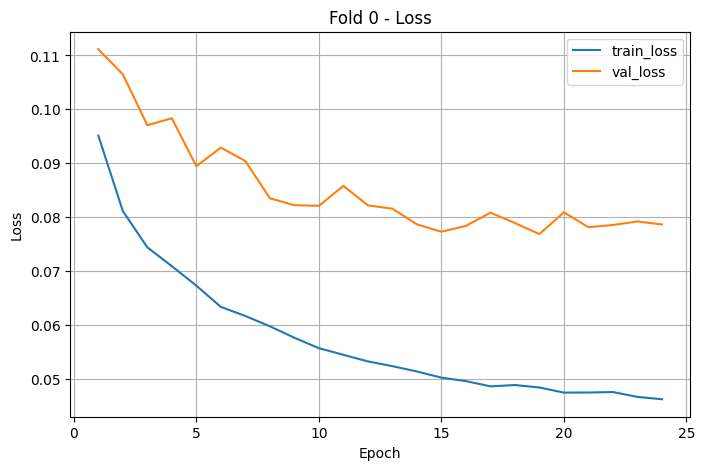

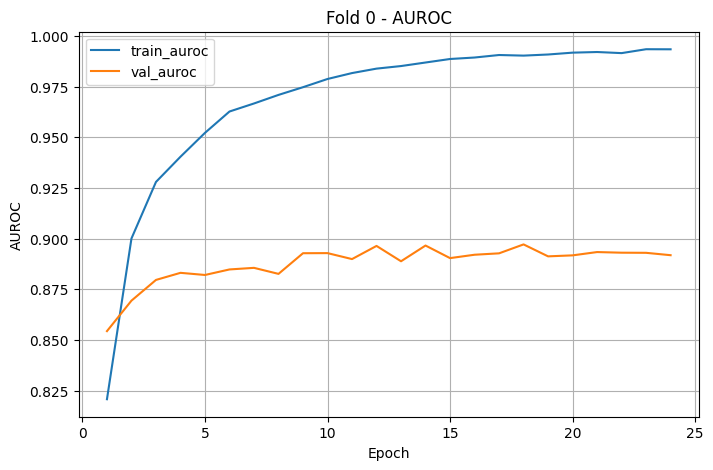

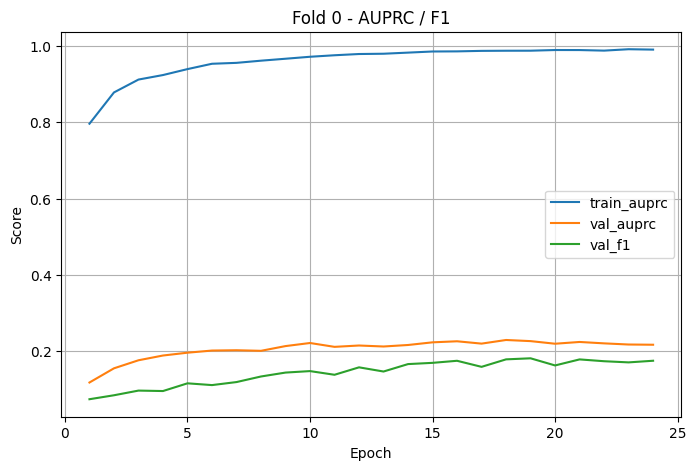

Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_0_loss.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_0_auroc.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_0_auprc_f1.png


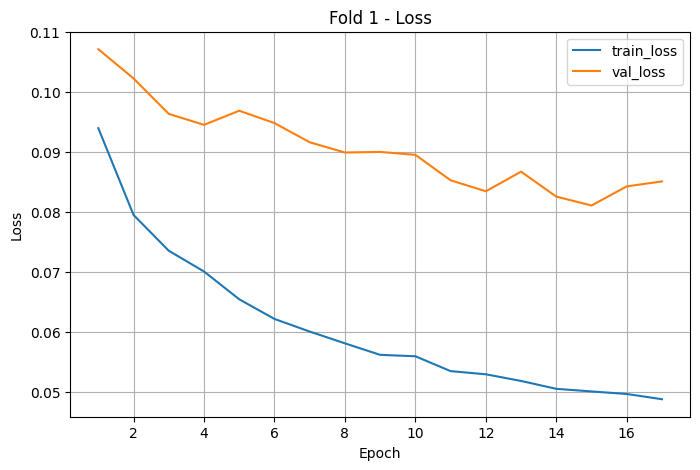

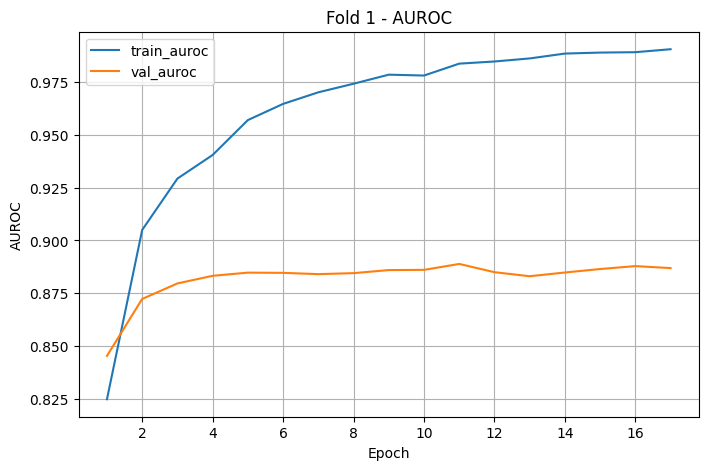

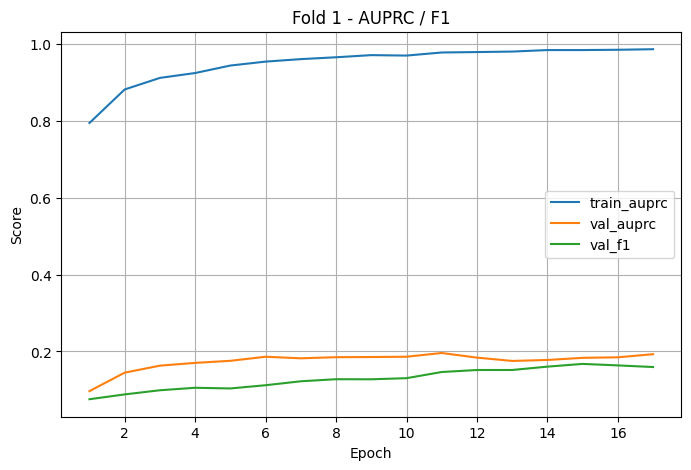

Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_1_loss.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_1_auroc.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_1_auprc_f1.png


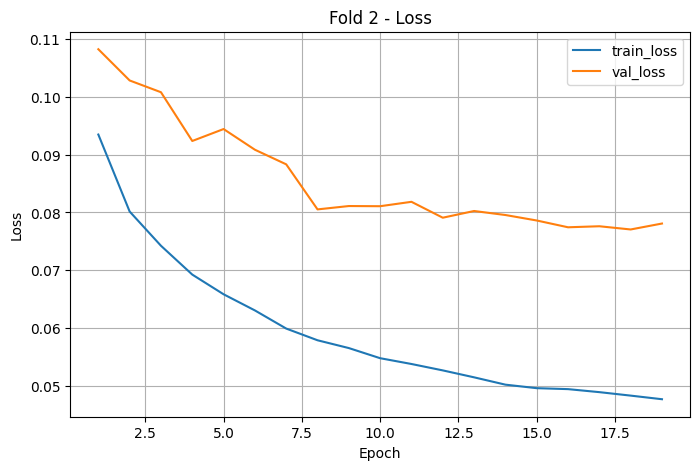

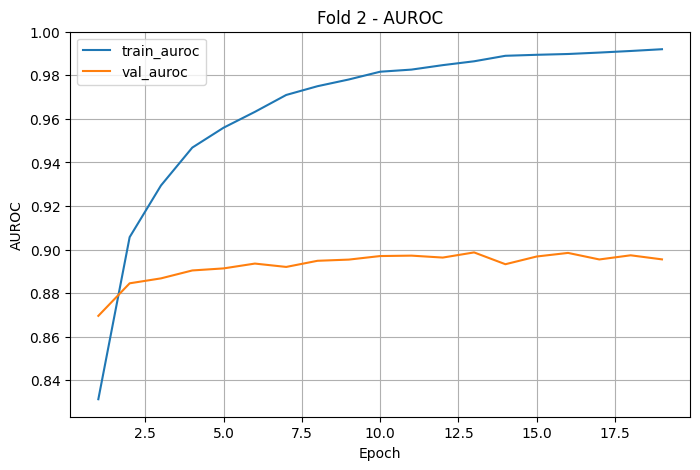

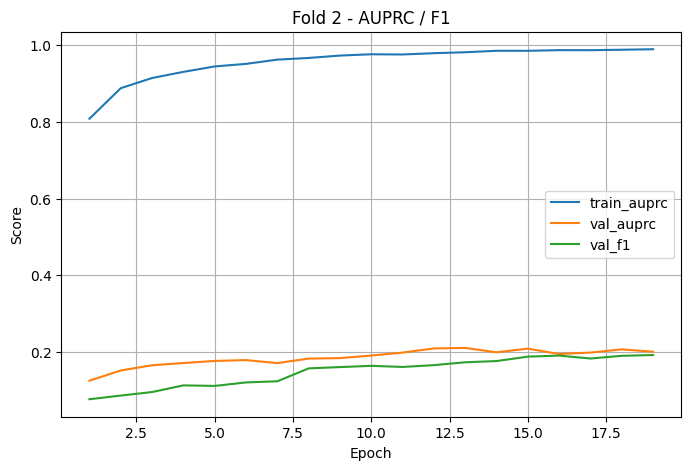

Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_2_loss.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_2_auroc.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_2_auprc_f1.png


In [23]:
for fold_idx in FOLDS_TO_RUN:
    history_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_history.csv"
    history_df = pd.read_csv(history_path)

    loss_plot_path  = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_loss.png"
    auroc_plot_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_auroc.png"
    score_plot_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_auprc_f1.png"

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold_idx} - Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # AUROC
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_auroc"], label="train_auroc")
    plt.plot(history_df["epoch"], history_df["val_auroc"], label="val_auroc")
    plt.xlabel("Epoch")
    plt.ylabel("AUROC")
    plt.title(f"Fold {fold_idx} - AUROC")
    plt.legend()
    plt.grid(True)
    plt.savefig(auroc_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # AUPRC / F1
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_auprc"], label="train_auprc")
    plt.plot(history_df["epoch"], history_df["val_auprc"], label="val_auprc")
    plt.plot(history_df["epoch"], history_df["val_f1"], label="val_f1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"Fold {fold_idx} - AUPRC / F1")
    plt.legend()
    plt.grid(True)
    plt.savefig(score_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {loss_plot_path}")
    print(f"Saved: {auroc_plot_path}")
    print(f"Saved: {score_plot_path}")

# OOF and TTA

In [24]:
USE_TTA_EVAL = False
WARMSTART_HYBRID = False
USE_ALL_DEV_CHECKPOINT = True

oof_probs = []
oof_labels = []
oof_records = []
fold_oof_results = []

for fold_idx, train_idx, val_idx in fold_splits:
    print(f"\n===== OOF evaluation fold {fold_idx} =====")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    val_loader = make_val_loader(val_df, fold_idx=fold_idx)

    model = build_model(
        fold_idx=fold_idx, 
        use_all_dev_checkpoint=USE_ALL_DEV_CHECKPOINT,
        warmstart_hybrid_from_frozen=WARMSTART_HYBRID)
    
    BEST_MODEL_PATH, _, _ = get_fold_paths(fold_idx)

    state_dict = torch.load(BEST_MODEL_PATH, map_location="cpu", weights_only=True)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

    criterion, _ = build_training_components(model, train_df)


    val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device,
        use_tta=USE_TTA_EVAL
    )

    fold_oof_results.append({
        "fold": fold_idx,
        "auroc": val_metrics["auroc"],
        "auprc": val_metrics["auprc"],
        "f1": val_metrics["f1"],
    })

    fold_probs = val_metrics["all_probs"]
    fold_labels = val_metrics["all_labels"]

    fold_pred_df = val_df[["image_name", "target"]].copy()
    fold_pred_df["fold"] = fold_idx
    fold_pred_df["prob"] = fold_probs
    fold_pred_df["pred_05"] = (fold_pred_df["prob"] >= 0.5).astype(int)

    fold_csv_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_val_predictions.csv"
    fold_pred_df.to_csv(fold_csv_path, index=False)
    print(f"Saved: {fold_csv_path}")

    oof_records.append(fold_pred_df)
    oof_probs.extend(fold_probs)
    oof_labels.extend(fold_labels)

oof_probs = np.array(oof_probs)
oof_labels = np.array(oof_labels)

oof_pred_df = pd.concat(oof_records, axis=0, ignore_index=True)
oof_pred_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_predictions.csv"
oof_pred_df.to_csv(oof_pred_path, index=False)

oof_auroc = roc_auc_score(oof_labels, oof_probs)
oof_auprc = average_precision_score(oof_labels, oof_probs)


# Define the path for the OOF summary text file
oof_summary_txt_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_summary.txt"

# Open the file in write mode ("w")
with open(oof_summary_txt_path, "w") as f:
    
    # Log per-fold metrics
    title_fold = "===== Per-fold OOF metrics ====="
    print(f"\n{title_fold}")
    f.write(f"{title_fold}\n")
    
    for result in fold_oof_results:
        line = (
            f"Fold {result['fold']} | "
            f"AUROC: {result['auroc']:.4f} | "
            f"AUPRC: {result['auprc']:.4f} | "
            f"F1@0.5: {result['f1']:.4f}"
        )
        print(line)
        f.write(f"{line}\n")
        
    # Log global metrics
    title_global = "===== Global OOF metrics ====="
    print(f"\n{title_global}")
    f.write(f"\n{title_global}\n")
    
    line_auroc = f"OOF AUROC: {oof_auroc:.4f}"
    line_auprc = f"OOF AUPRC: {oof_auprc:.4f}"
    
    print(line_auroc)
    print(line_auprc)
    f.write(f"{line_auroc}\n")
    f.write(f"{line_auprc}\n")

# Console confirmation
print(f"\nSaved OOF metrics summary to: {oof_summary_txt_path}")

oof_threshold_df = threshold_sweep(oof_labels, oof_probs)
oof_threshold_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_threshold_sweep.csv"
oof_threshold_df.to_csv(oof_threshold_path, index=False)

display(oof_threshold_df)

best_idx = oof_threshold_df["f1"].idxmax()
best_row = oof_threshold_df.loc[best_idx]
best_thr = float(best_row["threshold"])

print("\nBest OOF threshold by F1:")
print(best_row)

# APPEND BEST THRESHOLD TO THE SUMMARY TXT

with open(oof_summary_txt_path, "a") as f:  
    f.write("\n===== Best OOF Threshold by F1 =====\n")
    f.write(f"Threshold: {best_thr:.4f}\n")
    f.write(f"F1 Score:  {best_row['f1']:.4f}\n")
    f.write(f"Precision: {best_row['precision']:.4f}\n")
    f.write(f"Recall:    {best_row['recall']:.4f}\n")

print(f"\nAppended best threshold metrics to: {oof_summary_txt_path}")



===== OOF evaluation fold 0 =====
Loaded offline weights from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth


/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(


Loaded full hybrid checkpoint from: /user/HS401/ep01372/Documents/AML_Project/inputs/effb0_domainHybrid_customViT_v66_14x14_fusedSupCon_smooth_30ep_fold_0_best_model.pth
Missing keys: []
Unexpected keys: []
Reset Kaggle decision layers | gate: 0.047426 | gate_logit: -3.000000
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_0_val_predictions.csv

===== OOF evaluation fold 1 =====
Loaded offline weights from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth
Loaded full hybrid checkpoint from: /user/HS401/ep01372/Documents/AML_Project/inputs/effb0_domainHybrid_customViT_v66_14x14_fusedSupCon_smooth_30ep_fold_0_best_model.pth
Missing keys: []
Unexpected keys: []
Reset Kaggle decision layers | gate: 0.047426 | gate_logit: -3.000000


/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(


Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_1_val_predictions.csv

===== OOF evaluation fold 2 =====
Loaded offline weights from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth
Loaded full hybrid checkpoint from: /user/HS401/ep01372/Documents/AML_Project/inputs/effb0_domainHybrid_customViT_v66_14x14_fusedSupCon_smooth_30ep_fold_0_best_model.pth
Missing keys: []
Unexpected keys: []
Reset Kaggle decision layers | gate: 0.047426 | gate_logit: -3.000000


/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(


Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_2_val_predictions.csv

===== Per-fold OOF metrics =====
Fold 0 | AUROC: 0.8971 | AUPRC: 0.2290 | F1@0.5: 0.1782
Fold 1 | AUROC: 0.8889 | AUPRC: 0.1960 | F1@0.5: 0.1465
Fold 2 | AUROC: 0.8987 | AUPRC: 0.2102 | F1@0.5: 0.1727

===== Global OOF metrics =====
OOF AUROC: 0.8938
OOF AUPRC: 0.2091

Saved OOF metrics summary to: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_oof_summary.txt


,threshold,precision,recall,f1,specificity
0,0.05,0.022681,0.994863,0.044351,0.230686
1,0.10,0.032848,0.972603,0.063549,0.486080
2,0.15,0.041960,0.938356,0.080328,0.615512
3,0.20,0.049887,0.910959,0.094595,0.688649
4,0.25,0.056610,0.878425,0.106365,0.737293
5,0.30,0.063466,0.851027,0.118122,0.774630
6,0.35,0.070339,0.828767,0.129672,0.803423
7,0.40,0.077204,0.796233,0.140760,0.829205
8,0.45,0.084507,0.770548,0.152310,0.850194
9,0.50,0.092401,0.732877,0.164110,0.870813



Best OOF threshold by F1:
threshold      0.850000
precision      0.257790
recall         0.311644
f1             0.282171
specificity    0.983898
Name: 16, dtype: float64

Appended best threshold metrics to: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_oof_summary.txt


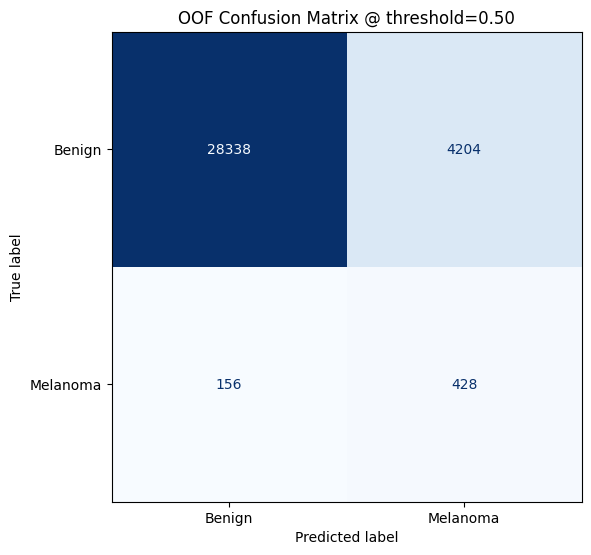

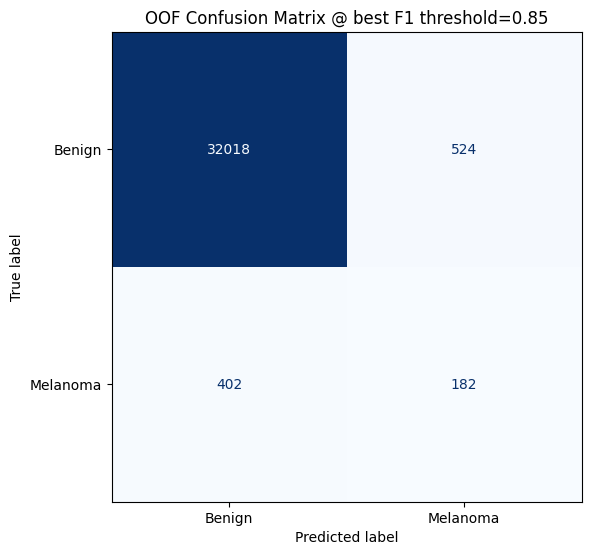


Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_oof_predictions.csv
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_oof_threshold_sweep.csv
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_oof_confusion_matrix_t050.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_oof_confusion_matrix_best_f1.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupC

In [25]:
def save_confusion_matrix_figure(y_true, y_prob, threshold, save_path, title):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    class_labels = ['Benign', 'Melanoma']

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "threshold": threshold,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
    }
    return metrics

cm_05_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_confusion_matrix_t050.png"
cm_best_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_confusion_matrix_best_f1.png"

cm_metrics_05 = save_confusion_matrix_figure(
    oof_labels,
    oof_probs,
    threshold=0.5,
    save_path=cm_05_path,
    title="OOF Confusion Matrix @ threshold=0.50"
)

cm_metrics_best = save_confusion_matrix_figure(
    oof_labels,
    oof_probs,
    threshold=best_thr,
    save_path=cm_best_path,
    title=f"OOF Confusion Matrix @ best F1 threshold={best_thr:.2f}"
)

oof_metrics = {
    "oof_auroc": float(oof_auroc),
    "oof_auprc": float(oof_auprc),
    "best_f1_threshold": best_thr,
    "cm_at_050": cm_metrics_05,
    "cm_at_best_f1": cm_metrics_best,
}

metrics_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_metrics.json"
with open(metrics_path, "w") as f:
    import json
    json.dump(oof_metrics, f, indent=2)

print(f"\nSaved: {oof_pred_path}")
print(f"Saved: {oof_threshold_path}")
print(f"Saved: {cm_05_path}")
print(f"Saved: {cm_best_path}")
print(f"Saved: {metrics_path}")

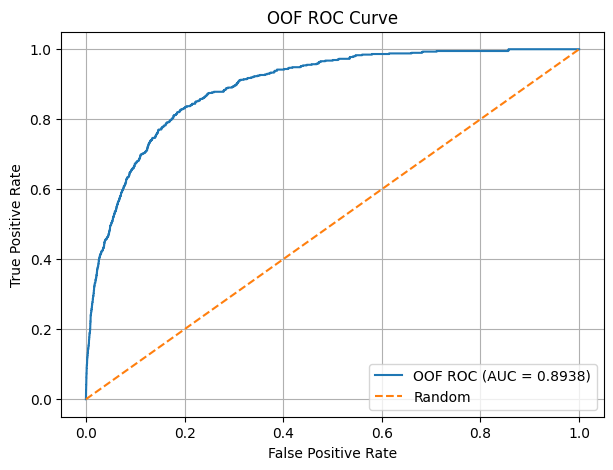

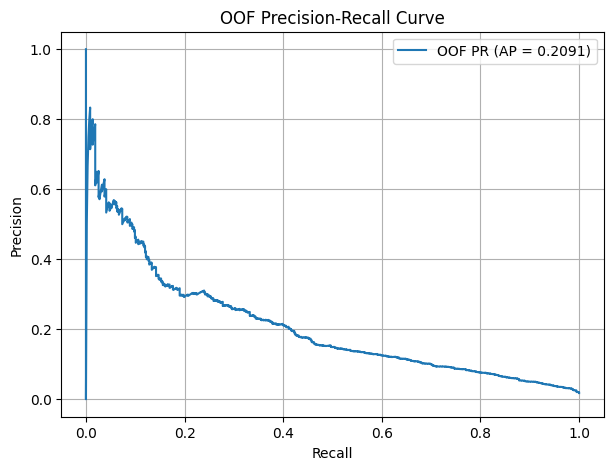

Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_oof_roc.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_oof_pr.png


In [26]:
roc_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_roc.png"
pr_path  = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_pr.png"


fpr, tpr, _ = roc_curve(oof_labels, oof_probs)
precision_pr, recall_pr, _ = precision_recall_curve(oof_labels, oof_probs)

roc_auc = oof_auroc
ap = oof_auprc

# ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"OOF ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("OOF ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(roc_path, bbox_inches="tight")
plt.show()

# PR
plt.figure(figsize=(7, 5))
plt.plot(recall_pr, precision_pr, label=f"OOF PR (AP = {ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("OOF Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.savefig(pr_path, bbox_inches="tight")
plt.show()

print("Saved:", roc_path)
print("Saved:", pr_path)

In [ ]:
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_gradcam_hybrid(model, image_tensor, target_class=1):
    model.eval()
    gradients, activations = [], []

    # Hook into the last CNN block
    target_layer = model.cnn.model.features[-1]

    fh = target_layer.register_forward_hook(lambda m, i, o: activations.append(o))
    bh = target_layer.register_full_backward_hook(lambda m, gi, go: gradients.append(go[0]))

    img = image_tensor.unsqueeze(0).to(device)
    logit = model(img)
    model.zero_grad()
    logit[0, 0].backward()

    fh.remove(); bh.remove()

    grads = gradients[0]
    acts  = activations[0]
    weights = grads.mean(dim=[2, 3], keepdim=True)
    cam = F.relu((weights * acts).sum(dim=1).squeeze())
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam.detach().cpu().numpy()


def show_gradcam_grid(model, val_df, transform, n=6):
    mel  = val_df[val_df["target"] == 1].sample(n//2, random_state=0)
    ben  = val_df[val_df["target"] == 0].sample(n//2, random_state=0)
    rows = pd.concat([mel, ben]).sample(frac=1, random_state=0)

    fig, axes = plt.subplots(2, n, figsize=(n*3, 6))
    for col, (_, row) in enumerate(rows.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB").resize((224, 224))
        tensor = transform(img)
        cam = get_gradcam_hybrid(model, tensor)
        cam_resized = cv2.resize(cam, (224, 224))
        heatmap = plt.cm.jet(cam_resized)[:, :, :3]
        overlay = np.array(img)/255.0 * 0.5 + heatmap * 0.5

        label = "Melanoma" if row["target"] == 1 else "Benign"
        axes[0, col].imshow(img); axes[0, col].set_title(f"True: {label}", fontsize=9); axes[0, col].axis("off")
        axes[1, col].imshow(overlay); axes[1, col].set_title("Grad-CAM", fontsize=9); axes[1, col].axis("off")

    plt.suptitle("Grad-CAM — Hybrid CNN-ViT Model", fontsize=12)
    plt.tight_layout()
    plt.savefig(WORKING_DIR / f"{EXPERIMENT_NAME}_gradcam.png", dpi=150)
    plt.show()

# Load best fold 0 model and run
model_gc = build_model(fold_idx=0, use_all_dev_checkpoint=False)
state = torch.load(get_fold_paths(0)[0], map_location="cpu", weights_only=True)
model_gc.load_state_dict(state, strict=True)
model_gc = model_gc.to(device)
show_gradcam_grid(model_gc, df.iloc[fold_splits[0][2]], val_transform, n=6)